In [1]:

import sys
import os
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath(".."))


from src.preprocess import pull_pitcher_data
from datetime import date
from dateutil.relativedelta import relativedelta

pitcher_first = 'Logan'
pitcher_last = 'Webb'

end_date = date.today().strftime("%Y-%m-%d")
start_date = (date.today() - relativedelta(years=1)).strftime("%Y-%m-%d")


df = pull_pitcher_data(pitcher_first, pitcher_last,start_date, end_date)
df.shape

Gathering player lookup table. This may take a moment.
Gathering Player Data


(3515, 139)

In [ ]:



import sys
import os
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath(".."))


from src.preprocess import pull_pitcher_data
from datetime import date
from dateutil.relativedelta import relativedelta

pitcher_first = 'Kevin'
pitcher_last = 'Gausman'

end_date = date.today().strftime("%Y-%m-%d")
start_date = (date.today() - relativedelta(years=2)).strftime("%Y-%m-%d")


df = pull_pitcher_data(pitcher_first, pitcher_last,start_date, end_date)
df.shape


features = ['balls', 'strikes', 'inning', 'outs_when_up','inning_top','pitch_type_map', 'batter_is_right', 'runner_on_first']
# ,
#             'prev_pitch_1_0.0',
#        'prev_pitch_1_1.0', 'prev_pitch_1_3.0', 'prev_pitch_1_4.0'
# features = [  #'prev_pitch_1_5.0']
# 'balls',
# 'strikes',
# 'outs_when_up',
# 'inning',
# 'pitch_type_map',
# 'prev_2_pitches_fb',
# 'runner_on_first',
# 'prev_pitch_was_fb',
# 'batter_is_right',
# 'inning_top',
# 'prev_pitch_1_0.0',
# 'prev_pitch_1_1.0', 
# 'prev_pitch_1_3.0', 
# 'prev_pitch_1_4.0']
      


df2 = df[features]




from datetime import date
from unicodedata import name
from dateutil.relativedelta import relativedelta
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np
import pandas as pd

from pybaseball import playerid_lookup
from xgboost import XGBClassifier 

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, log_loss, top_k_accuracy_score

df3 = df2.copy().dropna()

    # If after dropna we have too little data, skip
# if len(df3) < 200:
#     print(f"{name}: skipped (not enough after dropna)")
#     continue

X = df3.drop(columns=["pitch_type_map"])
y_raw = df3["pitch_type_map"]

# Time split: train first 65%, test last 35%
split_idx = int(len(df3) * 0.65)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_raw, y_test_raw = y_raw.iloc[:split_idx], y_raw.iloc[split_idx:]

# Encode labels based on TRAIN only
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)

# Filter out test rows with unseen classes (rare but possible in sparse pitch types)
seen = set(le.classes_)
mask = y_test_raw.isin(seen)
X_test_seen = X_test.loc[mask]
y_test_seen_raw = y_test_raw.loc[mask]
y_test = le.transform(y_test_seen_raw)


#sample_weights = compute_sample_weight('balanced', y_train)


         #,sample_weight=sample_weights)
num_classes = len(np.unique(y_train))
labels_for_metrics = np.arange(num_classes)

# XGBoost multiclass
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=43,
    n_jobs=-1,
    eval_metric="mlogloss",
)

xgb.fit(X_train, y_train)
        #, sample_weight=sample_weights)

y_pred = xgb.predict(X_test_seen)
y_proba = xgb.predict_proba(X_test_seen)


acc = accuracy_score(y_test, y_pred)
f1_w = f1_score(y_test, y_pred, average="weighted")
f1_m = f1_score(y_test, y_pred, average="macro")
ll = log_loss(y_test, y_proba, labels=labels_for_metrics)
top2 = top_k_accuracy_score(y_test, y_proba, k=2, labels=labels_for_metrics)

# Baseline log loss: training distribution (IMPORTANT: use TRAIN distribution, not resampled)
# Use y_train (pre-SMOTE) because baseline should reflect real pitcher tendencies.
base_probs = np.bincount(y_train, minlength=len(le.classes_)) / len(y_train)
baseline_probs = np.tile(base_probs, (len(y_test), 1))

# But if we filtered test unseen classes, baseline_probs needs to match encoded class count.
# le.classes_ corresponds to labels 0..K-1 where K=len(le.classes_)
baseline_ll = log_loss(y_test, baseline_probs, labels=np.arange(len(le.classes_)))
improvement = baseline_ll - ll

print({
    "pitcher": name,
    "n_train": len(y_train),
    "n_test": len(y_test),
    "baseline_ll": baseline_ll,
    "model_ll": ll,
    "improvement": improvement,
    "accuracy": acc,
    "f1_weighted": f1_w,
    "f1_macro": f1_m,
    "top2_acc": top2,
    "classes": len(le.classes_),
})

print(f"{name}: baseline_ll={baseline_ll:.4f} model_ll={ll:.4f} diff={improvement:.4f}   acc={acc:.3f} top2={top2:.3f}")

Gathering Player Data
{'pitcher': <built-in function name>, 'n_train': 4317, 'n_test': 2325, 'baseline_ll': 0.9782739096019235, 'model_ll': 0.9614760685704193, 'improvement': 0.016797841031504168, 'accuracy': 0.5273118279569893, 'f1_weighted': 0.49723068867895936, 'f1_macro': 0.27547311769524646, 'top2_acc': 0.9027956989247312, 'classes': 4}
<built-in function name>: baseline_ll=0.9783 model_ll=0.9615 diff=0.0168   acc=0.527 top2=0.903


: 

In [31]:
df['pitch_type_map'].value_counts()/sum(df['pitch_type_map'].value_counts())

pitch_type_map
3.0    0.333099
0.0    0.331696
4.0    0.161200
2.0    0.100509
5.0    0.059814
1.0    0.013682
Name: count, dtype: float64

Classification Report:
              precision    recall  f1-score   support

    Fastball       0.32      0.46      0.38       674
      Sinker       0.48      0.35      0.40       577
   Curveball       0.00      0.00      0.00        56
      Slider       0.18      0.06      0.09       325
    Changeup       0.37      0.45      0.40       705

    accuracy                           0.36      2337
   macro avg       0.27      0.26      0.26      2337
weighted avg       0.35      0.36      0.34      2337



c:\Users\cstone\Downloads\VS Code\MLB Pitch Prediction\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cstone\Downloads\VS Code\MLB Pitch Prediction\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\cstone\Downloads\VS Code\MLB Pitch Prediction\ds\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

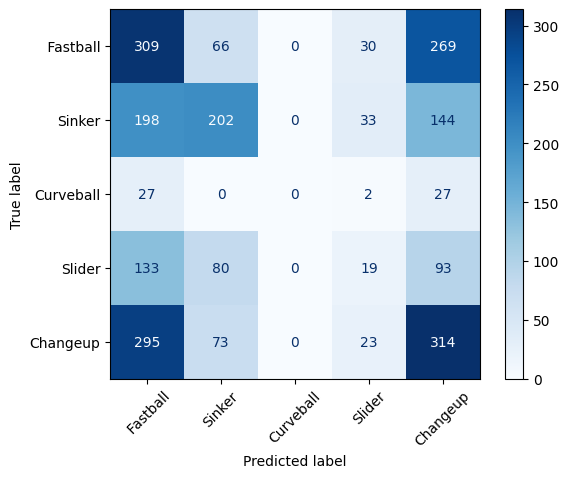

In [29]:
class_mapping = {0: ' Fastball',
                1: 'Sinker',
                2: 'Curveball',
                3: 'Slider',
                4: 'Changeup',
                5: 'Cutter',
                6: 'Knuckle'}


# lr_predictions = lr_model.predict(X_test)
# y_pred_prob = lr_model.predict_proba(X_test)

# print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_predictions))
# print("Logistic Regression F1 Score:", f1_score(y_test, lr_predictions, average='weighted'))



from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
class_labels = df['pitch_type_map'].unique()


print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=[class_mapping[c] for c in np.unique(y_raw)]))
conf_matrix = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[class_mapping[c] for c in np.unique(y_raw)])
disp.plot(cmap="Blues", xticks_rotation=45)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

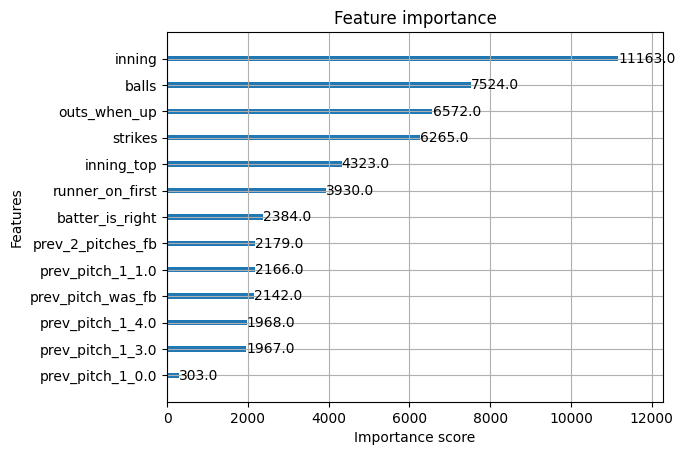

In [27]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

X_features = [  #'prev_pitch_1_5.0']
'balls',
'strikes',
'outs_when_up',
'inning',

'prev_2_pitches_fb',
'runner_on_first',
'prev_pitch_was_fb',
'batter_is_right',
'inning_top',
'prev_pitch_1_0.0',
'prev_pitch_1_1.0', 
'prev_pitch_1_3.0', 
'prev_pitch_1_4.0']
xgb.get_booster().feature_names = X_features

from xgboost import plot_importance
plot_importance(xgb)

In [ ]:
import sys
import os
import pandas as pd
import numpy as np

sys.path.append(os.path.abspath(".."))


from src.preprocess import pull_pitcher_data
from datetime import date
from dateutil.relativedelta import relativedelta

pitchers = [
    "Logan Webb", "Garrett Crochet", "Cristopher Sánchez", "Max Fried", "Carlos Rodón",
    "Tarik Skubal", "Kevin Gausman", "Zac Gallen", "Framber Valdez", "Paul Skenes",
    "Zack Littell", "Bryan Woo", "Hunter Brown", "Merrill Kelly", "Jesús Luzardo",
    "Tanner Bibee", "Robbie Ray", "Nick Pivetta", "Luis Castillo", "Sonny Gray",
    "Jake Irvin", "Matthew Boyd", "Yusei Kikuchi", "Freddy Peralta", "Brandon Pfaadt"
]

def train_and_evaluate(pitcher_first, pitcher_last, years_back=2):

    end_date = date.today().strftime("%Y-%m-%d")
    start_date = (date.today() - relativedelta(years=years_back)).strftime("%Y-%m-%d")

    df = pull_pitcher_data(pitcher_first, pitcher_last,start_date, end_date)
    


    features = ['balls', 'strikes', 'inning', 'outs_when_up','inning_top','pitch_type_map', 'batter_is_right', 'runner_on_first']



df2 = df[features]




from datetime import date
from unicodedata import name
from dateutil.relativedelta import relativedelta
from sklearn.utils.class_weight import compute_sample_weight
import numpy as np
import pandas as pd

from pybaseball import playerid_lookup
from xgboost import XGBClassifier 

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, log_loss, top_k_accuracy_score

df3 = df2.copy().dropna()

    # If after dropna we have too little data, skip
# if len(df3) < 200:
#     print(f"{name}: skipped (not enough after dropna)")
#     continue

X = df3.drop(columns=["pitch_type_map"])
y_raw = df3["pitch_type_map"]

# Time split: train first 65%, test last 35%
split_idx = int(len(df3) * 0.65)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_raw, y_test_raw = y_raw.iloc[:split_idx], y_raw.iloc[split_idx:]

# Encode labels based on TRAIN only
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)

# Filter out test rows with unseen classes (rare but possible in sparse pitch types)
seen = set(le.classes_)
mask = y_test_raw.isin(seen)
X_test_seen = X_test.loc[mask]
y_test_seen_raw = y_test_raw.loc[mask]
y_test = le.transform(y_test_seen_raw)


#sample_weights = compute_sample_weight('balanced', y_train)


         #,sample_weight=sample_weights)
num_classes = len(np.unique(y_train))
labels_for_metrics = np.arange(num_classes)

# XGBoost multiclass
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=43,
    n_jobs=-1,
    eval_metric="mlogloss",
)

xgb.fit(X_train, y_train)
        #, sample_weight=sample_weights)

y_pred = xgb.predict(X_test_seen)
y_proba = xgb.predict_proba(X_test_seen)


acc = accuracy_score(y_test, y_pred)
f1_w = f1_score(y_test, y_pred, average="weighted")
f1_m = f1_score(y_test, y_pred, average="macro")
ll = log_loss(y_test, y_proba, labels=labels_for_metrics)
top2 = top_k_accuracy_score(y_test, y_proba, k=2, labels=labels_for_metrics)

# Baseline log loss: training distribution (IMPORTANT: use TRAIN distribution, not resampled)
# Use y_train (pre-SMOTE) because baseline should reflect real pitcher tendencies.
base_probs = np.bincount(y_train, minlength=len(le.classes_)) / len(y_train)
baseline_probs = np.tile(base_probs, (len(y_test), 1))

# But if we filtered test unseen classes, baseline_probs needs to match encoded class count.
# le.classes_ corresponds to labels 0..K-1 where K=len(le.classes_)
baseline_ll = log_loss(y_test, baseline_probs, labels=np.arange(len(le.classes_)))
improvement = baseline_ll - ll

print({
    "pitcher": name,
    "n_train": len(y_train),
    "n_test": len(y_test),
    "baseline_ll": baseline_ll,
    "model_ll": ll,
    "improvement": improvement,
    "accuracy": acc,
    "f1_weighted": f1_w,
    "f1_macro": f1_m,
    "top2_acc": top2,
    "classes": len(le.classes_),
})

print(f"{name}: baseline_ll={baseline_ll:.4f} model_ll={ll:.4f} diff={improvement:.4f}   acc={acc:.3f} top2={top2:.3f}")